<a href="https://colab.research.google.com/github/sthefany-vg/Decision-Aid/blob/main/DAPPC_LAB2_SOM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# DAPPC - LAB 2
## Identification of Homogeneous Groups of Patients with SOMs

In this notebook you will:

1. Load a prepared dataset  
2. Select the variables used for clustering  
3. Normalize the input features  
4. Define and train a square Self-Organizing Map (SOM)  
5. Extract the weight matrix of the trained SOM  
6. Apply hierarchical clustering on neuron weights  
7. Visualize the dendrogram and define the number of clusters  
8. Build the sample hits map and identify contiguous neuron bubbles  
9. Assign each subject to a winner neuron, a neuron cluster, and a bubble  
10. Save the results

We assume:
- The dataset is already prepared and filled (it has no MVs)
- Each row corresponds to one subject
- Subject identifiers are available in the first six columns of the dataset


## 0) Setup


In [ ]:
!pip install minisom -q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from matplotlib.patches import RegularPolygon
from matplotlib import cm, colors

from collections import deque
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from minisom import MiniSom


  Preparing metadata (setup.py) ... done


## 1) Load Dataset


In [ ]:
# === TODO: update path and sheet name ===
# Actualizamos al nombre exacto de tu archivo de datos imputados
file_path = 'Dataset_DAPPC_2026_Cleaned_kNN.xlsx'
sheet_name = 'Dataset_step_3b'  # O el nombre específico de la pestaña que desees cargar

# Cargamos el archivo de Excel
df = pd.read_excel(file_path, sheet_name=sheet_name)

print("Initial shape:", df.shape)
df.head()


Initial shape: (3893, 76)


,subject_id,hadm_id,stay_id,ICU,ICU_intime,ICU_outtime,gender,age,weight,charlson_comorbidity_index,...,first_plateau_pressure,std_plateau_pressure,vent_duration_hours,outcome,comorb_cardiac_cardiovascular,comorb_respiratory_pulmonary,comorb_metabolic_endocrine_renal,comorb_neurological_neuromuscular_psychiatric,comorb_systemic_immune_oncologic,comorb_total
0,13710366,26676995,36043579,1,2172-04-05 04:00:00,2172-04-09 08:17:22,1,66,113.3,3,...,19.0,1.909727,96.0,2,0,0,1,0,0,1
1,12970079,23949170,36004625,1,2164-12-22 19:48:19,2165-01-03 21:30:54,1,53,106.7,5,...,10.0,8.337289,230.0,1,0,1,1,0,0,2
2,17682100,22097504,34901461,1,2173-08-23 01:12:00,2173-08-27 21:28:52,0,66,46.1,6,...,17.0,1.224745,34.0,1,0,0,1,0,0,1
3,15545849,24922530,39025631,3,2172-08-02 16:32:00,2172-09-09 12:44:11,1,49,106.0,1,...,11.0,4.877563,399.0,2,1,0,1,1,0,3
4,10288279,21750307,34078845,1,2114-09-07 20:19:42,2114-09-15 13:24:09,0,77,49.3,7,...,17.0,3.239768,155.0,2,1,0,1,0,1,3


## 2) Column Index Table


In [ ]:
display(pd.DataFrame({
    "index": np.arange(df.shape[1]),
    "column_name": df.columns,
    "dtype": df.dtypes
}))


,index,column_name,dtype
subject_id,0,subject_id,int64
hadm_id,1,hadm_id,int64
stay_id,2,stay_id,int64
ICU,3,ICU,int64
ICU_intime,4,ICU_intime,object
...,...,...,...
comorb_respiratory_pulmonary,71,comorb_respiratory_pulmonary,int64
comorb_metabolic_endocrine_renal,72,comorb_metabolic_endocrine_renal,int64
comorb_neurological_neuromuscular_psychiatric,73,comorb_neurological_neuromuscular_psychiatric,int64
comorb_systemic_immune_oncologic,74,comorb_systemic_immune_oncologic,int64



## 3) Select Variables for SOM

Define here the variables that will be used to build the SOM.

You can specify them either:
- by column indices, or  
- by explicit column names.

Remember that we're going to use a clustering method (unsupervised learning approach).

In [ ]:

# ============================================================
# 1. Define variable groups: you should obtain the names of the all the input features
# ============================================================

# Variables continuas (parámetros de laboratorio y signos vitales)
continuous_vars = [
    "weight", "first_pCO2", "std_pCO2", "first_pH", "std_pH", "first_pO2", "std_pO2",
    "first_PT", "std_PT", "first_PTT", "std_PTT", "std_chloride", "first_creatinine",
    "std_creatinine", "first_glycemia", "std_glycemia", "first_hemoglobin", "std_hemoglobin",
    "first_phosphate", "std_phosphate", "std_platelets", "first_potassium", "std_potassium",
    "std_sodium", "first_wbc", "std_wbc", "first_diastolic_blood_pressure", "std_diastolic_blood_pressure",
    "first_mean_blood_pressure", "std_mean_blood_pressure", "first_systolic_blood_pressure",
    "std_systolic_blood_pressure", "first_heart_rate", "std_heart_rate", "first_respiratory_rate",
    "std_respiratory_rate", "first_temperature", "std_temperature", "first_PEEP", "std_PEEP",
    "first_PIP", "std_PIP", "first_mean_airway_pressure", "std_mean_airway_pressure",
    "first_plateau_pressure", "std_plateau_pressure", "vent_duration_hours", "sedative_duration_hours"
]

# Variables enteras (escalas y recuentos analíticos)
integer_vars = [
    "age", "charlson_comorbidity_index", "gcs", "sofa", "sirs", "sapsii",
    "comorb_total", "first_chloride", "first_platelets", "first_sodium"
]

# Variables categóricas binarias (tratamientos y categorías de comorbilidades)
categorical_vars = [
    "gender", "vasopressors", "sedatives", "neuromuscular_blockers", "steroids", "opioids",
    "comorb_cardiac_cardiovascular", "comorb_respiratory_pulmonary",
    "comorb_metabolic_endocrine_renal", "comorb_neurological_neuromuscular_psychiatric",
    "comorb_systemic_immune_oncologic"
]

# Unimos todas las características clínicas para el entrenamiento del SOM
input_features = continuous_vars + integer_vars + categorical_vars

# Extraemos la matriz de datos X aislando las variables seleccionadas
X = df[input_features].copy()

print("Number of selected variables:", len(input_features))
print("First selected variable:", input_features[0])
print("Last selected variable:", input_features[-1])
print("Last selected variable:", input_features[-1])


Number of selected variables: 69
First selected variable: weight
Last selected variable: comorb_systemic_immune_oncologic
Last selected variable: comorb_systemic_immune_oncologic



## 4) Normalize the Input Features

Since SOM training is distance-based, the variables must be on a comparable scale. Here we use min-max scaling.


In [ ]:
# 4) Normalize the Input Features
# Inicializamos el escalador Min-Max
scaler = MinMaxScaler()

# Ajustamos el escalador y transformamos la matriz de características X
# Convertimos el resultado de vuelta a un DataFrame para mantener los nombres e índices intactos
X_norm = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

print("Dimensiones de la matriz normalizada:", X_norm.shape)
print("Rango de valores mínimos (deben ser 0):", X_norm.min().min())
print("Rango de valores máximos (deben ser 1):", X_norm.max().max())

Dimensiones de la matriz normalizada: (3893, 69)
Rango de valores mínimos (deben ser 0): 0.0
Rango de valores máximos (deben ser 1): 1.0000000000000002



## 6) Define and Train the SOM

Main steps:
1. Define the dimension of the square SOM  
2. Create the SOM architecture  
3. Initialize the neuron weights  
4. Train the SOM


In [ ]:
# ============================================================
# 1. Define the dimensions of the SOM (square SOM)
# ============================================================
# Usamos la regla de Vesanto para 3893 pacientes: 5 * sqrt(3893) -> ~18x18 neuronas
n = 18

# ============================================================
# 2. Create the SOM architecture
# ============================================================
som = MiniSom(
    x=n,
    y=n,
    input_len=X_norm.shape[1],
    sigma=4,
    learning_rate=0.3,
    activation_distance='euclidean',
    topology='hexagonal',
    neighborhood_function='gaussian',
)

# ============================================================
# 3. Initialize and train the SOM
# ============================================================
# Inicializamos las neuronas proyectando pesos aleatorios basados en los límites de X_norm
som.random_weights_init(X_norm.values)

# Entrenamos usando las filas completas del dataset en modo epochs
som.train(X_norm.values, num_iteration=200, use_epochs=True) #it may take a while (usually around 5-10 minutes)

print(f"Trained SOM: {n} x {n}")

Trained SOM: 18 x 18



## 7) Save the Trained SOM

The trained SOM can be saved and reused later without retraining.


In [ ]:
 # adjust the filename and the directory in which you want to save the SOMs
som_filename = f"SOM_Dim_{n}x{n}.pkl"

with open(som_filename, 'wb') as f:
    pickle.dump(som, f)

print("Saved SOM to:", som_filename)


Saved SOM to: SOM_Dim_18x18.pkl



## 8) Extract the Weight Matrix

Each neuron of the trained SOM is associated with one weight vector.

We extract the neuron weights and reshape them into a 2D matrix:
- one row per neuron  
- one column per feature


In [ ]:
# Check that the wight shapes are (number of neurons, number of features)
weights_3d = som.get_weights()
weights = weights_3d.reshape(n * n, X.shape[1])
print("Weight matrix shape:", weights.shape)


Weight matrix shape: (324, 69)



## 9) Hierarchical Clustering on SOM Weights

We now apply agglomerative hierarchical clustering to the neuron weights.

As in the previous laboratory, we use:
- complete linkage  
- cityblock distance

Yuo're appling hierarchical clustering on SOM's neurons so the numbers on the x-axis represent the position of each neuron in the 2D Network -> the first (neuron number 0) is the top-left corner, the last one is the right-bottom corner.

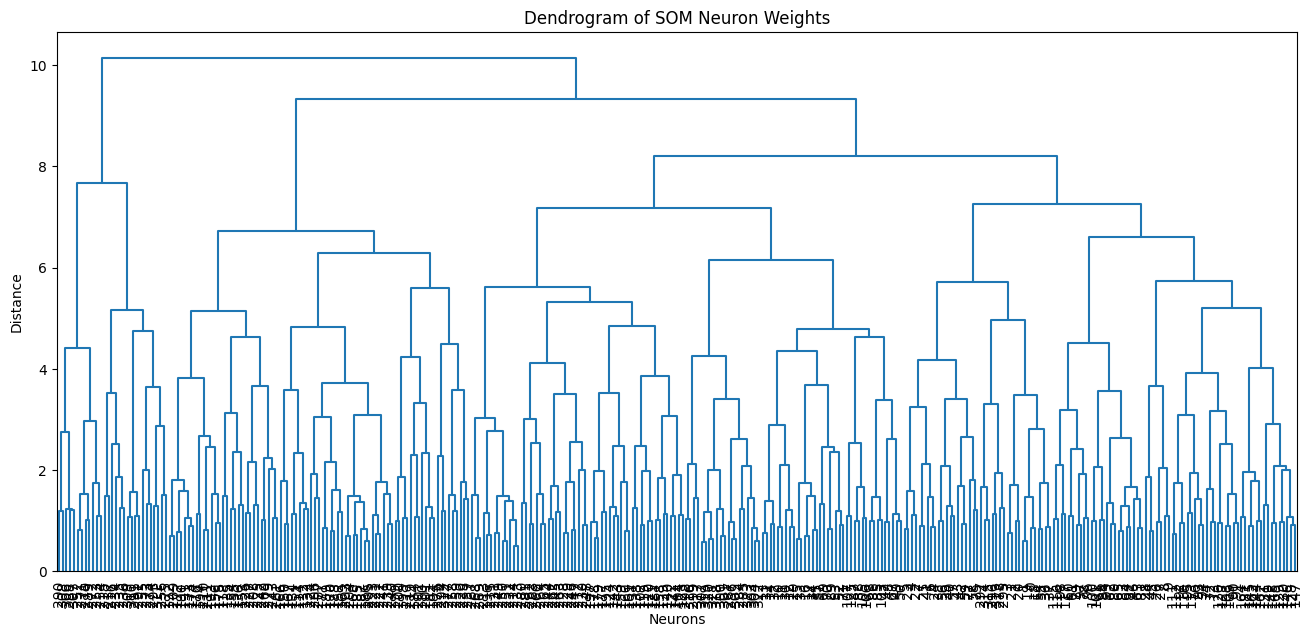

In [ ]:
# ============================================================
# Compute the hierarchical clustering tree
# ============================================================
Z = linkage(weights, method='complete', metric='cityblock')

# ============================================================
# Visualize the dendrogram and try to identify the nubmer of clusters of neurons
# ============================================================
fig, ax = plt.subplots(figsize=(16, 7))
dendrogram(Z, color_threshold=0) # adjust threshold according to the number of cluster you want to obtain
ax.tick_params(axis='x', labelsize=10, labelrotation=90)
ax.set_title('Dendrogram of SOM Neuron Weights')
ax.set_xlabel('Neurons')
ax.set_ylabel('Distance')
plt.show()



## 10) Define the Number of Clusters

Choose the number of clusters by cutting the dendrogram.

The variable `numCl` can be changed according to the desired partition.


In [ ]:
# you may need to insert some codes above to define the number of cluster (compute the metrics and evaluate them)
from sklearn.metrics import silhouette_score

# ============================================================
# Evaluación Matemática del Número de Clusters (Métrica de Silueta)
# ============================================================
best_score = -1
optimal_clusters = 4  # Valor por defecto inicial

print("--- Evaluación del Silhouette Score para los Pesos del SOM ---")
for k_test in range(2, 16):
    # Cortamos el árbol jerárquico para 'k_test' clusters
    labels_test = fcluster(Z, t=k_test, criterion='maxclust')

    # Calculamos la silueta usando la misma métrica que el linkage ('cityblock')
    score = silhouette_score(weights, labels_test, metric='cityblock')
    print(f"Clusters: {k_test} | Silhouette Score: {score:.4f}")

    if score > best_score:
        best_score = score
        optimal_clusters = k_test

# ============================================================
# 10) Define the Number of Clusters
# ============================================================
# Asignamos automáticamente el número óptimo detectado por la métrica.
# Puedes cambiar este valor manualmente si el dendrograma visual sugiere otra estructura clara.
numCl = optimal_clusters

# Cluster label of each neuron (fcluster devuelve etiquetas del 1 al numCl)
clusterIdx = fcluster(Z, t=numCl, criterion='maxclust')

# 2D cluster map of the SOM neurons (Regresamos las etiquetas al formato 18x18 de la rejilla)
cluster_map = clusterIdx.reshape(n, n)

print("\n=============================================================")
print("PROCESAMIENTO DE CLUSTERS NEURONALES")
print("=============================================================")
print("Number of neuron clusters:", numCl)
print("Dimensión de la matriz topológica de clusters:", cluster_map.shape)

--- Evaluación del Silhouette Score para los Pesos del SOM ---
Clusters: 2 | Silhouette Score: 0.3070
Clusters: 3 | Silhouette Score: 0.2375
Clusters: 4 | Silhouette Score: 0.2244
Clusters: 5 | Silhouette Score: 0.2047
Clusters: 6 | Silhouette Score: 0.1978
Clusters: 7 | Silhouette Score: 0.1909
Clusters: 8 | Silhouette Score: 0.1865
Clusters: 9 | Silhouette Score: 0.2086
Clusters: 10 | Silhouette Score: 0.2080
Clusters: 11 | Silhouette Score: 0.2181
Clusters: 12 | Silhouette Score: 0.2075
Clusters: 13 | Silhouette Score: 0.2142
Clusters: 14 | Silhouette Score: 0.2184
Clusters: 15 | Silhouette Score: 0.2167

PROCESAMIENTO DE CLUSTERS NEURONALES
Number of neuron clusters: 2
Dimensión de la matriz topológica de clusters: (18, 18)



## 12) Identify Contiguous Neuron Bubbles

A bubble is defined as a group of neighboring neurons that:
- belong to the same neuron cluster  
- are contiguous on the SOM grid

Here we identify the connected components of the 2D cluster map using 4-neighborhood connectivity.
The function below helps you to visualize the bubble of neurons (i.e., groups of neighbour neurons). You can use this function to check if the groups are contigous or not.

The function create a figure with two subplots:
- On the lift side you can see the map of victories of the SOM. The number inside each neuron is the number of victories.
- On the righ side, you can see the neurons divided into N groups (N is the umber of clusters you defined before) with a colormap. The number inside is the cluster label.

You can also modify the function if you want to plot other information rather than the default ones.

In [ ]:
def plot_som_hits_and_bubbles_side_by_side(
    som,
    hits,
    cluster_map,
    hex_radius=0.85 / np.sqrt(3),
    hits_cmap='Blues',
    bubbles_cmap='jet',
    hits_title='Hits Map',
    bubbles_title='Neuron Bubbles'
):
    """
    Plot the SOM hits map and the neuron bubble map side by side.

    Parameters
    ----------
    som : MiniSom
        Trained SOM object.
    hits : ndarray of shape (n_rows, n_cols)
        Number of wins for each neuron.
    cluster_map : ndarray of shape (n_rows, n_cols)
        Cluster label assigned to each neuron.
    hex_radius : float, default=0.85 / sqrt(3)
        Radius of each hexagon.
    hits_cmap : str, default='Blues'
        Colormap used for the hits map.
    bubbles_cmap : str, default='jet'
        Colormap used for the bubble map.
    hits_title : str, default='Hits Map'
        Title of the hits subplot.
    bubbles_title : str, default='Neuron Bubbles'
        Title of the bubble subplot.
    """

    # --------------------------------------------------------
    # 1. Extract SOM geometry
    # --------------------------------------------------------
    weights_3d = som.get_weights()
    n_rows, n_cols, _ = weights_3d.shape
    xx, yy = som.get_euclidean_coordinates()

    # --------------------------------------------------------
    # 2. Colormaps
    # --------------------------------------------------------
    hits_cmap_obj = cm.get_cmap(hits_cmap)
    max_hits = np.max(hits) if np.max(hits) > 0 else 1
    hits_norm = colors.Normalize(vmin=0, vmax=max_hits)

    num_clusters = int(np.max(cluster_map))
    bubbles_cmap_obj = cm.get_cmap(bubbles_cmap, num_clusters)

    # --------------------------------------------------------
    # 3. Create figure and axes
    # --------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    ax_hits, ax_bubbles = axes

    # --------------------------------------------------------
    # 4. Common axis formatting
    # --------------------------------------------------------
    def format_axis(ax):
        ax.set_aspect('equal')

        # Tick labels arranged for didactic reading:
        # left-to-right, top-to-bottom
        ax.set_xticks(np.arange(n_cols))
        ax.set_yticks(np.arange(n_rows) * np.sqrt(3) / 2)

        ax.set_xticklabels(np.arange(n_cols))
        ax.set_yticklabels(np.arange(n_rows - 1, -1, -1))

        yy_plot = yy * np.sqrt(3) / 2
        ax.set_xlim(xx.min() - 1, xx.max() + 1)
        ax.set_ylim(yy_plot.min() - 1, yy_plot.max() + 1)

    # --------------------------------------------------------
    # 5. Left subplot: hits map
    # --------------------------------------------------------
    for i in range(n_rows):
        for j in range(n_cols):
            # Visual arrangement:
            # row i is displayed from top to bottom
            # column j is displayed from left to right
            i_plot = n_rows - 1 - i
            j_plot = j

            wx = xx[(j_plot, i_plot)]
            wy = yy[(j_plot, i_plot)] * np.sqrt(3) / 2

            hit_value = hits[i, j]
            face_color = hits_cmap_obj(hits_norm(hit_value))

            hexagon = RegularPolygon(
                (wx, wy),
                numVertices=6,
                radius=hex_radius,
                facecolor=face_color,
                edgecolor='lightgray',
                linewidth=1.2
            )
            ax_hits.add_patch(hexagon)

            text_color = 'white' if hit_value > 0.6 * max_hits else 'black'
            ax_hits.text(
                wx, wy,
                str(hit_value),
                ha='center',
                va='center',
                fontsize=10,
                fontweight='bold',
                color=text_color
            )

    format_axis(ax_hits)
    ax_hits.set_title(hits_title, fontweight='bold')

    # --------------------------------------------------------
    # 6. Right subplot: bubble map
    # --------------------------------------------------------
    for i in range(n_rows):
        for j in range(n_cols):
            i_plot = n_rows - 1 - i
            j_plot = j

            wx = xx[(j_plot, i_plot)]
            wy = yy[(j_plot, i_plot)] * np.sqrt(3) / 2

            cluster_id = cluster_map[i, j]
            cluster_color = bubbles_cmap_obj(cluster_id - 1)

            hexagon = RegularPolygon(
                (wx, wy),
                numVertices=6,
                radius=hex_radius,
                facecolor=cluster_color,
                edgecolor=cluster_color,
                alpha=0.28,
                linewidth=2
            )
            ax_bubbles.add_patch(hexagon)

            ax_bubbles.text(
                wx, wy,
                str(cluster_id),
                ha='center',
                va='center',
                fontsize=10,
                fontweight='bold',
                color='black'
            )

    format_axis(ax_bubbles)
    ax_bubbles.set_title(bubbles_title, fontweight='bold')

    plt.tight_layout()
    plt.show()

Here there's an example of how to use the function as it's written right now. If you change something in the function you may have to adjust also how you call it.

In [ ]:
# Compute som hits (wins)
hits = np.zeros((n, n), dtype=int)
for x in X_norm:
    i, j = som.winner(x)
    hits[i, j] += 1

# Plot som hits and bubbles
plot_som_hits_and_bubbles_side_by_side(
    som=som,
    hits=hits,
    cluster_map=cluster_map
)

UFuncTypeError: ufunc 'subtract' did not contain a loop with signature matching types (dtype('<U6'), dtype('float64')) -> None


## 14) Assign Subjects to Neurons, Clusters, and Bubbles

Each subject is assigned to:
- the winner neuron  
- the cluster of the winner neuron  
- the contiguous bubble containing the winner neuron


In [ ]:
# ============================================================
# 14) Assign Subjects to Neurons, Clusters, and Bubbles
# Assign each subject to the cluster of its winner neuron
# ============================================================

subject_winners = []
subject_clusters = []

# Recorremos cada fila (paciente) de la matriz normalizada
for x in X_norm.values:
    # 1. Encontramos la neurona ganadora (BMU) para el paciente actual
    # Devuelve una tupla con las coordenadas (fila_neurona, col_neurona)
    winner = som.winner(x)

    # 2. Extraemos el Cluster ID correspondiente usando las coordenadas de la neurona
    # Recuerda que cluster_map tiene dimensiones (n, n)
    cluster_id = cluster_map[winner[0], winner[1]]

    subject_winners.append(winner)
    subject_clusters.append(cluster_id)

# Convertimos a arreglos de NumPy para facilitar su manipulación
subject_winners = np.array(subject_winners)
subject_clusters = np.array(subject_clusters)

# Construimos la tabla de resumen final vinculando el ID real del paciente
# Usamos df.iloc[:, 0] como respaldo si la columna exacta no se llama 'subject_id'
id_column = 'subject_id' if 'subject_id' in df.columns else df.columns[0]

subjects_clustered = pd.DataFrame({
    'subject_id': df[id_column].values,
    'winner_neuron_row': subject_winners[:, 0],
    'winner_neuron_col': subject_winners[:, 1],
    'cluster_id': subject_clusters
})

subjects_clustered.head()

,subject_id,winner_neuron_row,winner_neuron_col,cluster_id
0,13710366,13,13,2
1,12970079,3,17,2
2,17682100,10,0,2
3,15545849,3,0,2
4,10288279,17,12,2



## 15) Explore the Subjects in Each Cluster

The following cell prints the number of subjects assigned to each cluster and each bubble. Modify it if you want to analyze something more.


In [ ]:

print("Subjects per cluster:")
cluster_summary = (
    subjects_clustered
    .groupby('cluster_id')
    .size()
    .reset_index(name='n_subjects')
    .sort_values(by='cluster_id')
)

cluster_summary

Subjects per cluster:


,cluster_id,n_subjects
0,1,363
1,2,3530



## 16) Save the Final Results

Save the subject assignments as a file (.csv or .xlsx or whatever you prefer).

You can also save one file per cluster if you prefer. Remember to restore the information about the IDs (first 6 columns) and the outcome (last column) of the initial dataset.


In [ ]:
# ============================================================
# 16) Save the Final Results
# ============================================================

# 1. Extraemos los bloques originales respetando la estructura del dataset
df_ids = df.iloc[:, :6].copy()       # Conservamos exactamente las primeras 6 columnas de IDs
df_outcome = df.iloc[:, -1:].copy()   # Aislamos la última columna que representa el outcome (0, 1, 2)

# 2. Inicializamos el DataFrame consolidado partiendo de los identificadores
df_final_results = df_ids.copy()

# 3. Insertamos los descriptores topológicos obtenidos mediante el SOM y Clustering
df_final_results['winner_neuron_row'] = subjects_clustered['winner_neuron_row']
df_final_results['winner_neuron_col'] = subjects_clustered['winner_neuron_col']
df_final_results['som_cluster_id'] = subjects_clustered['cluster_id']

# 4. Concatenamos las características clínicas normalizadas (o las originales de df[input_features])
# Es altamente recomendado guardar las originales para que las unidades sean interpretables por un médico
df_final_results = pd.concat([df_final_results, df[input_features]], axis=1)

# 5. Colocamos el outcome como la última columna absoluta del dataset estructurado
df_final_results['outcome'] = df_outcome.values

print("--- Validación de la Estructura Final ---")
print("Dimensiones finales del dataset consolidado:", df_final_results.shape)
print("Primeras 9 columnas:", list(df_final_results.columns[:9]))
print("Última columna:", df_final_results.columns[-1])

# 6. Guardado centralizado en tu archivo de Excel kNN usando el modo append ('a')
results_filename = 'Dataset_DAPPC_2026_Cleaned_kNN.xlsx'
new_sheet_name = "SOM_Assignments"

with pd.ExcelWriter(results_filename, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    df_final_results.to_excel(writer, sheet_name=new_sheet_name, index=False)

print("\n=============================================================")
print(f"¡ÉXITO TOTAL! Asignaciones de pacientes guardadas correctamente.")
print(f"Archivo: '{results_filename}' | Hoja: '{new_sheet_name}'")
print("=============================================================")

--- Validación de la Estructura Final ---
Dimensiones finales del dataset consolidado: (3893, 79)
Primeras 9 columnas: ['subject_id', 'hadm_id', 'stay_id', 'ICU', 'ICU_intime', 'ICU_outtime', 'winner_neuron_row', 'winner_neuron_col', 'som_cluster_id']
Última columna: outcome

¡ÉXITO TOTAL! Asignaciones de pacientes guardadas correctamente.
Archivo: 'Dataset_DAPPC_2026_Cleaned_kNN.xlsx' | Hoja: 'SOM_Assignments'


In [ ]:

results_filename = ...
print("Saved subject assignments to:", results_filename)
